In [1]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
from graph_utils import LJInteractionParams, prepare_traj
from itpo_weights import DatasetType
from pressure import compute_total_stress

# from simulator_model import Model as VelocityModel
from simulator_SA_cpu_test import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import (
    calc_p_ratio_box_tensor,
    get_rollout,
    load_and_split_dataset,
    # simulate_then_rollout,
    visualize_nu_disribution,
)


### Load Data

Loading data with max simulation length of 300...


test  data: 100%|██████████| 125/125 [00:04<00:00, 26.07it/s]



Preparing data...


test  data: 100%|██████████| 125/125 [00:08<00:00, 15.42it/s]



Train data: 250 sims.
Val data:   125 sims.
Test data:  125 sims.


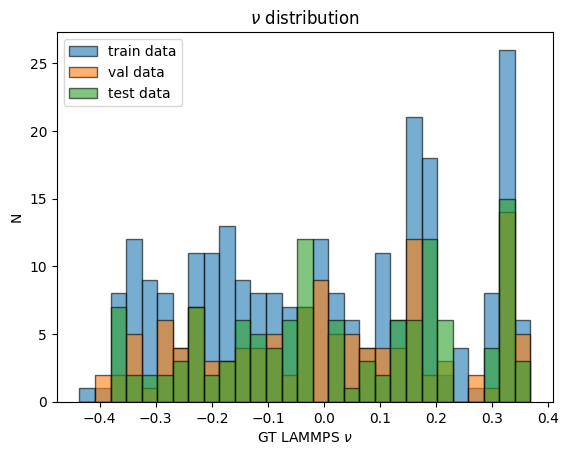

In [2]:
poisson_buckets = [
    {"max": 0.1, "count": 300},                # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 100},    # 0.1 <= P < 0.2
    {"min": 0.2, "count": 100}                 # P >= 0.2
]

# poisson_buckets = [
#     {"min": 0.0, "max": 1.0, "count": 400},   # full range
# ]

dataset_type = DatasetType.NodeOptimized

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    registry_path="./data/data_registry.csv",
    # registry_path="./data_reid_with_angles/data_registry.csv",
    # registry_path="./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 300
print(f"Loading data with max simulation length of {max_sim_len}...")
# stride = 5
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        lj_params = LJInteractionParams(0.01, 1.0, 1.122) if dataset_type is DatasetType.LJNoisy else None
        prepared_sim = prepare_traj(sim, lj_params, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")

visualize_nu_disribution(data)


### Initialize pretrained models

In [65]:
mp_layers = 2
mlp = 3
hidden_size = 128
history = 3
device = "cuda"

init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, 4)))

models = {}

# model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
# model.load_checkpoint(f"./new_trained_models/{dataset_type}/OST/model_h{history}_nl{mp_layers}_mlp{mlp}_epochs150.pt")
# model = freeze_normalizer(model)
# models[f"h{3} P>0.1 ost"] = model

# model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
# model.load_checkpoint(f"./trained_models/{dataset_type}/OST/model_P>0.2_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
# model = freeze_normalizer(model)
# models[f"h{3} P>0.2 ost"] = model

# model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
# model.load_checkpoint(f"./new_trained_models/{dataset_type}/MST/model_h{history}_nl{mp_layers}_mlp{mlp}_epochs150.pt")
# model = freeze_normalizer(model)
# models[f"h{3} P>0.1 mst new"] = model

# model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
# model.load_checkpoint(f"./trained_models/{dataset_type}/MST/model_P>0.1_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
# model = freeze_normalizer(model)
# models[f"h{3} P>0.1 mst old"] = model

for i in range(120, 121, 2):
    model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
    model_path = f"./new_trained_models/node_optimized/MST/checkpoint_epoch_{i}.pt"
    model.load_checkpoint(model_path)
    model = freeze_normalizer(model)
    model_name = f"h{3} mst epoch {i} new"
    models[model_name] = model

# i = 20
# model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
# model.load_checkpoint(f"./new_trained_models/{dataset_type}/MST/checkpoint_epoch_{i}.pt")
# model = freeze_normalizer(model)
# models[f"h{3} mst epoch {i}"] = model

print(f"Dataset type: {dataset_type}")
for i, model_name in enumerate(models.keys()):
    print(f"    {i+1}. Model {model_name}.")

Successfully loaded and migrated LEGACY checkpoint from ./new_trained_models/node_optimized/MST/checkpoint_epoch_120.pt
Dataset type: node_optimized
    1. Model h3 mst epoch 120 new.


### Testing models

#### Test model performance

In [62]:
num_steps = 50
model_results = {}
test_models = models

if dataset_type is DatasetType.NodeOptimized:
    barostat_config = barostat_parameters.node_optimizated
elif dataset_type is DatasetType.StiffOptimized:
    barostat_config = barostat_parameters.stiff_optimized
elif dataset_type is DatasetType.StiffAngles:
    barostat_config = barostat_parameters.stiff_angles
elif dataset_type is DatasetType.Noisy:
    barostat_config = barostat_parameters.noisy
elif dataset_type is DatasetType.LJNoisy:
    barostat_config = barostat_parameters.lj_noisy

name_len = max([len(n) for n in test_models])+1 

for model_name, model in test_models.items():
    model.eval()

    history = int(model_name[1])
    target_idx = num_steps + history + 1
    results = {
        "gt_box_velocity": [],
        "pred_box_velocity": [],
        "final_mse": [],
        "mse": [],
        "est_p": [],
        "pred_p": [],
        "gt_est_p": [],
        "gt_p": [],
        "gt_box": [],
        "pred_box": [],
        "gt_forces": [],
        "pred_forces": [],
        "gt_pressure": [],
        "pred_pressure": [],
    }

    with torch.no_grad():
        for val_sim in tqdm(data['test'], desc=f"Model {model_name:<{name_len}}"):

            # This block computes dumping period (N MD steps in 1 dump step)        
            sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
            assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
            dump_period = int(assumed_rollout_length / len(val_sim)) + 1

            barostat_config_current = deepcopy(barostat_config)
            barostat_config_current["default_skip"] = dump_period

            input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]

            rollout = get_rollout(
                input_graphs=input_graphs,
                gnn_simulator=model,
                gnn_history=history,
                num_steps=num_steps,
                barostat_config=barostat_config_current,
                lj_params=lj_params,
                device="cuda"
            )

            # rollout = simulate_then_rollout(
            #     starting_graph=input_graphs[0],
            #     gnn_simulator=model,
            #     gnn_history=history,
            #     barostat_config=barostat_config_current,
            #     md_steps=(history + 1) * dump_period,
            #     rollout_steps=num_steps,
            #     device="cuda"
            # )

            # Compare Predicted Position vs Ground Truth Position
            pos_mse = torch.nn.functional.mse_loss(rollout[-1].pos.cpu(), val_sim[target_idx].to(device).pos.cpu()).item()
            results["final_mse"].append(pos_mse)
            pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
            results["mse"].append(pos_mse)
            
            pred_p = calc_p_ratio_box_tensor(rollout).item()
            results["pred_p"].append(pred_p)
            gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
            results["gt_p"].append(gt_p)

            pred_box = [g.box_tensor.cpu() for g in rollout]
            results["pred_box"].append(pred_box)
            gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
            results["gt_box"].append(gt_box)

            r0 = val_sim[0].edge_attr[:, -2]
            gt_pressure = torch.stack([compute_total_stress(g, r0=r0.to(g.x.device), temperature=1e-7).cpu() for g in val_sim[:len(rollout)]], dim=0)
            results['gt_pressure'].append(gt_pressure)
            pred_pressure = torch.stack([compute_total_stress(g, r0=r0.to(g.x.device), temperature=1e-7).cpu() for g in rollout], dim=0)
            results["pred_pressure"].append(pred_pressure)

    model_results[model_name] = results

Model h3 mst epoch 125 new : 100%|██████████| 125/125 [00:14<00:00,  8.43it/s]


#### Parity plots for GT and predicted $\nu$

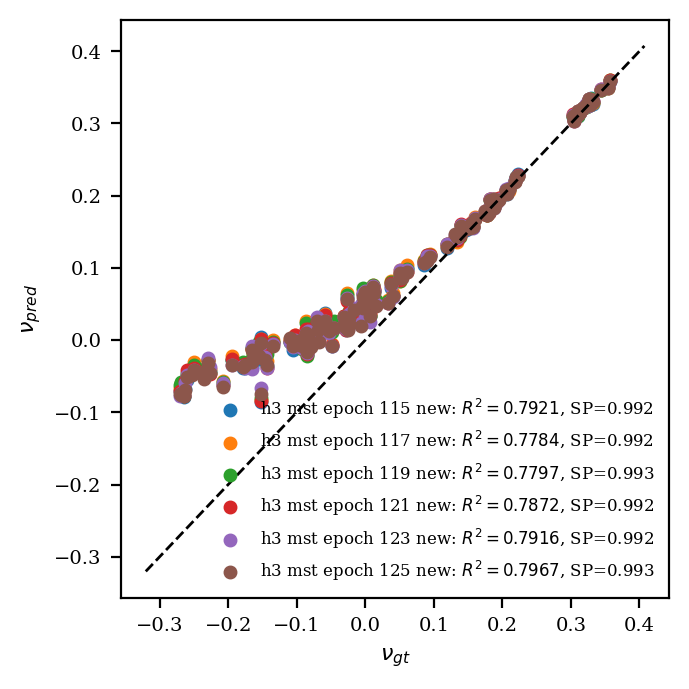

In [63]:
params = {
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'lines.markersize': 4,
    'figure.figsize': (3.33, 3.33),
    'figure.dpi': 200,
    'font.family': 'serif',
}
plt.rcParams.update(params)

fig, ax = plt.subplots(1, 1, layout="constrained")

line = (min(results["gt_p"]) - 0.05, max(results["gt_p"]) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, results in model_results.items():

    r2 = r2_score(results['gt_p'], results['pred_p'])
    res = spearmanr(results["gt_p"], results["pred_p"])
    sp = res.statistic
    
    label_text = f"{model_name}: $R^2={r2:.4f}$, SP={sp:.3f}"
    ax.scatter(results["gt_p"], results["pred_p"], label=label_text)
    
ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")
# ax.set_ylim(-0.4, 0.4)

plt.show()


#### MSE as a function of strain

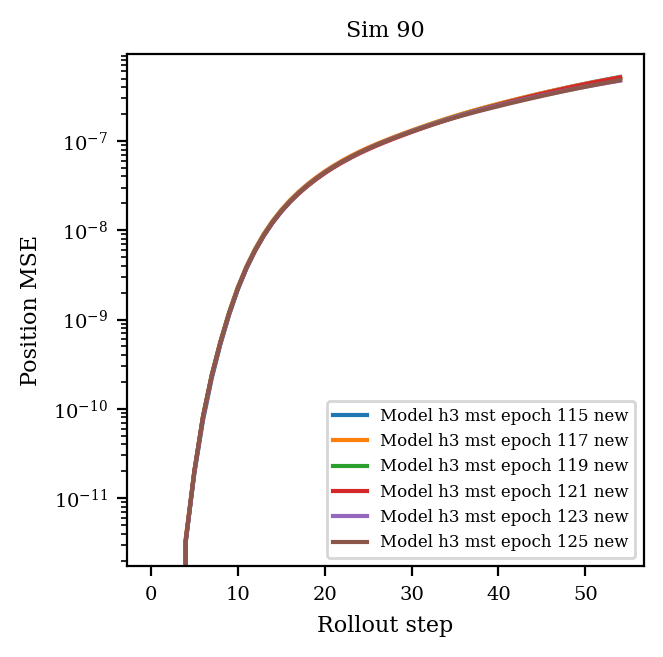

In [64]:
rand_sim = random.randint(0, len(results['mse'])-1)
for model_name, results in model_results.items():
    plt.plot(results["mse"][rand_sim], label=f"Model {model_name}")

plt.legend()
plt.yscale('log')
plt.title(f"Sim {rand_sim}")
plt.xlabel('Rollout step')
plt.ylabel('Position MSE')
plt.show()

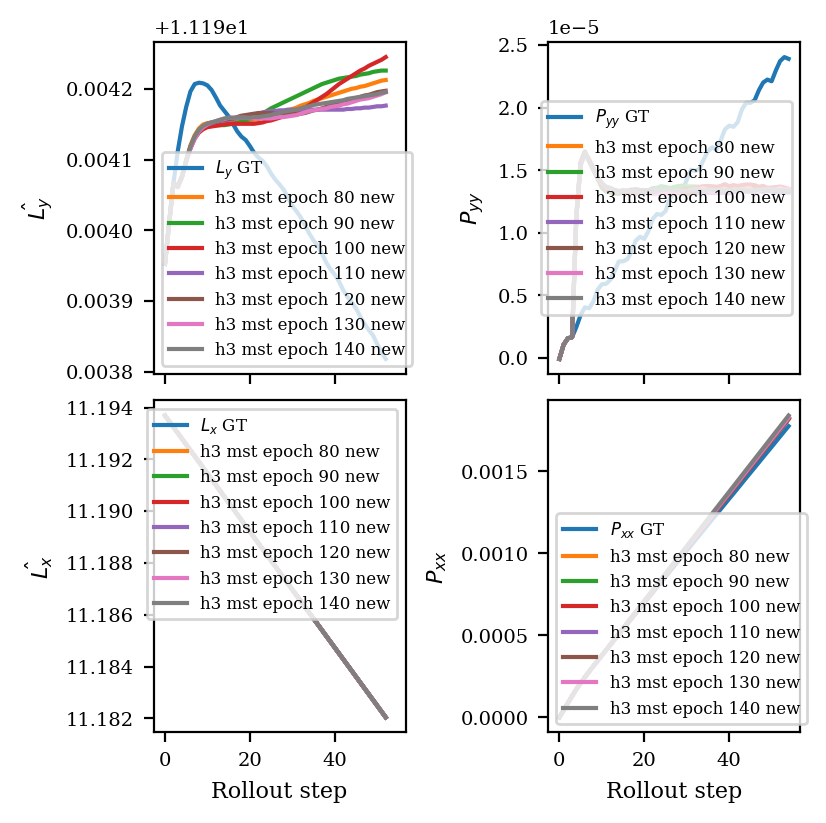

In [42]:
rand = random.randint(0, len(results) - 1)

fig, ax = plt.subplots(2, 2, layout="constrained", figsize=(4, 4), sharex=True)

any_key = random.sample(sorted(model_results.keys()), k=1)[0]
box_y_true = [model_results[any_key]["gt_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
box_x_true = [model_results[any_key]["gt_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

pressure_gt = results["gt_pressure"][rand]

ax[0][0].plot(box_y_true, label="$L_y$ GT")
ax[1][0].plot(box_x_true, label="$L_x$ GT")
ax[0][1].plot(pressure_gt[:, 1], label="$P_{{yy}}$ GT")
ax[1][1].plot(pressure_gt[:, 0], label="$P_{{xx}}$ GT")


for model_name, results in model_results.items():

    box_y_roll = [results["pred_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
    box_x_roll = [results["pred_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

    pressure_roll = results["pred_pressure"][rand]

    ax[0][0].plot(box_y_roll, label=model_name)
    ax[0][0].set_ylabel(r"$\hat{L_y}$")
    ax[0][0].legend()

    ax[1][0].plot(box_x_roll, label=model_name)
    ax[1][0].set_ylabel(r"$\hat{L_x}$")
    ax[1][0].set_xlabel("Rollout step")
    ax[1][0].legend()

    ax[0][1].plot(pressure_roll[:, 1], label=model_name)
    ax[0][1].set_ylabel(r"$P_{yy}$")
    ax[0][1].legend()
    
    ax[1][1].plot(pressure_roll[:, 0], label=model_name)
    ax[1][1].set_ylabel(r"$P_{xx}$")
    ax[1][1].set_xlabel("Rollout step")
    ax[1][1].legend()

plt.show()


### Stress vs. strain

/tmp/ipykernel_15462/2164367808.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_fit = np.array(gt_stress[:fit_to_steps, 0])


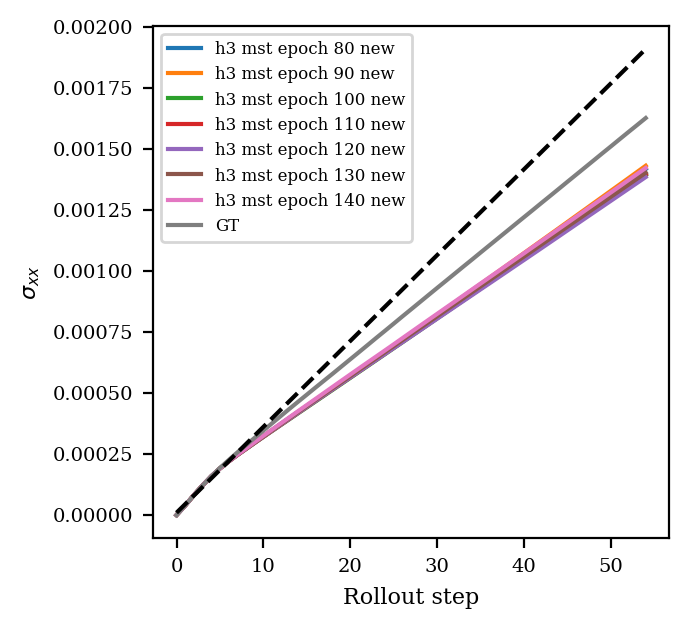

In [46]:
random_result = random.randint(0, len(model_results[sorted(model_results.keys())[0]])-1)

for model_name, result in model_results.items():
    pred_stress = result['pred_pressure'][random_result]
    pred_pressure = torch.abs(pred_stress[:, 0] + pred_stress[:, 1]) / 2

    # plt.plot(pred_pressure, label=f"{model_name}")
    plt.plot(pred_stress[:, 0], label=f"{model_name}")


# Plot GT pressure
gt_stress = model_results[sorted(model_results.keys())[0]]['gt_pressure'][0]
gt_pressure = torch.abs(gt_stress[:, 0] + gt_stress[:, 1]) / 2
# plt.plot(gt_pressure, label="GT")
plt.plot(gt_stress[:, 0], label="GT")

# Plot linear fit
fit_to_steps = 10
x_fit = np.array(range(fit_to_steps))
gt_stress = model_results[sorted(model_results.keys())[0]]['gt_pressure'][0]
gt_pressure = torch.abs(gt_stress[:, 0] + gt_stress[:, 1]) / 2

# y_fit = np.array(gt_pressure[:fit_to_steps])
y_fit = np.array(gt_stress[:fit_to_steps, 0])
a, b = np.polyfit(x_fit, y_fit, deg=1)
linear = [a*i + b for i in range(len(gt_pressure))]

plt.plot(linear, linestyle="--", color="black")
plt.ylabel(r"$\sigma_{xx}$")
plt.xlabel(r"Rollout step")
plt.legend()
plt.show()
